In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display


In [6]:
# =========================
# Config
# =========================
ticker    = "QQQ"                 # single-asset test
start     = "2012-01-01"
end       = None                  # None = today
ma_range  = range(50, 301, 10)    # 50..300 step 10

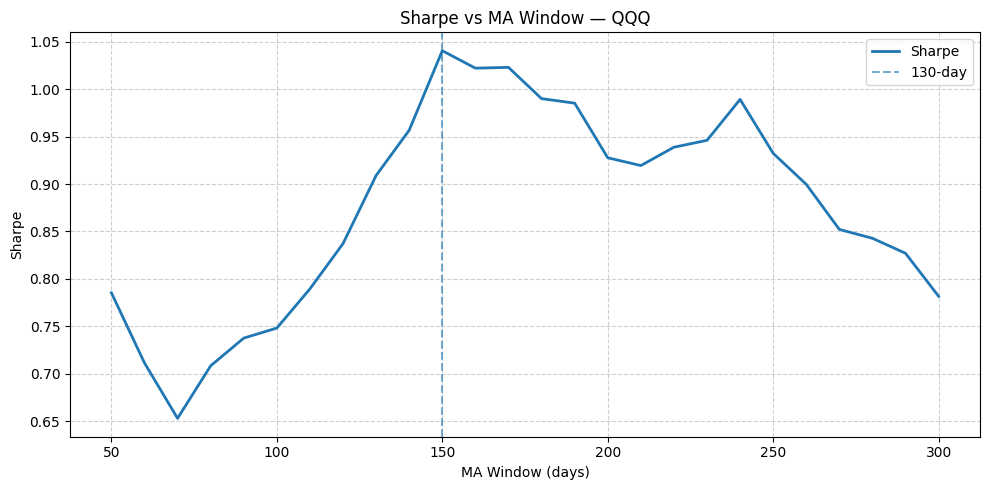

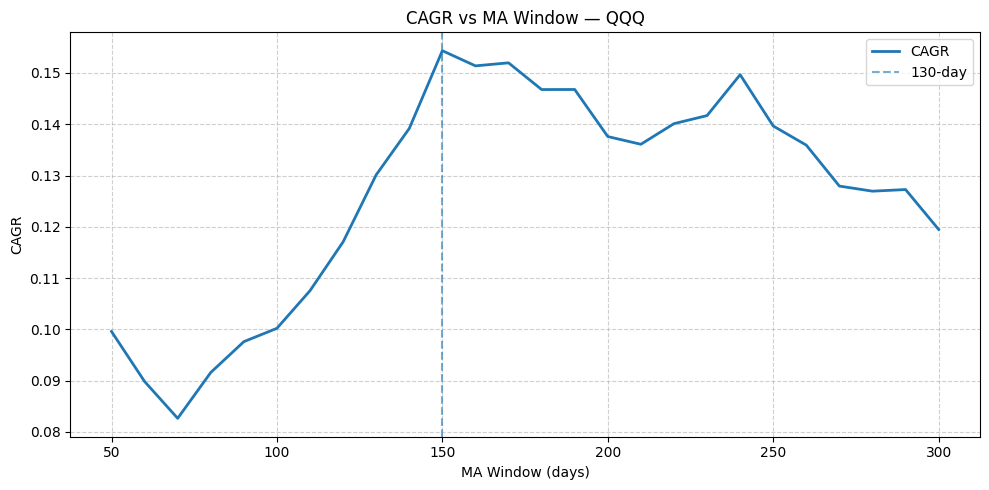

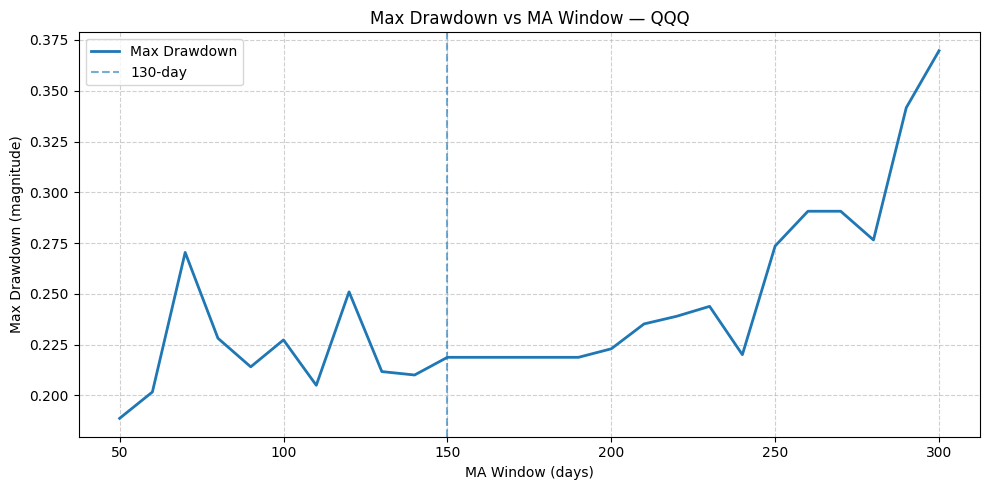

In [7]:
# =========================
# Data (force Series)
# =========================
data = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)


# If multiple tickers were passed, 'Close' will be a DataFrame.
px = data["Adj Close"]
if isinstance(px, pd.DataFrame):
    px = px.iloc[:, 0]   # take first column (since ticker="SPY", this extracts the 1D series)
px = px.sort_index()     # ensure chronological order
ret = px.pct_change()


# =========================
# Helpers (coerce to float to avoid ambiguity)
# =========================
def kpi_from_equity(eq: pd.Series):
    eq = eq.dropna()
    if eq.empty or len(eq) < 2:
        return np.nan, np.nan, np.nan

    r = eq.pct_change().dropna()
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = (eq.iloc[-1] / eq.iloc[0])**(1/yrs) - 1 if yrs > 0 else np.nan

    vol = float(r.std()) * np.sqrt(252)   # <-- make scalar
    sharpe = (r.mean() * 252) / vol if vol > 0 else np.nan

    mdd = float((eq / eq.cummax() - 1).min()) if not eq.empty else np.nan
    return cagr, sharpe, abs(mdd)

# =========================
# Backtest each MA (no look-ahead)
# =========================
rows = []
for L in ma_range:
    ma  = px.rolling(L).mean().shift(1)
    sig = (px > ma).astype(int)
    sig_prev = sig.shift(1)

    daily_ret = (ret * sig_prev).fillna(0.0)
    equity = (1 + daily_ret).cumprod()
    if not equity.empty:
        equity.iloc[0] = 1.0

    # KPIs
    cagr, sharpe, mdd = kpi_from_equity(equity)


    rows.append((L, cagr, sharpe, mdd))

res = pd.DataFrame(
    rows,
    columns=["MA_Length", "CAGR", "Sharpe", "MaxDD"]
).set_index("MA_Length")

best_ma_length = res.sort_values("Sharpe", ascending=False).index[0]


# =========================
# Sharpe vs MA Window
# =========================
plt.figure(figsize=(10, 5))
plt.plot(res.index, res["Sharpe"], linewidth=2, label="Sharpe")
plt.axvline(best_ma_length, linestyle="--", alpha=0.6, label="130-day")
plt.title(f"Sharpe vs MA Window — {ticker}")
plt.xlabel("MA Window (days)")
plt.ylabel("Sharpe")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



# =========================
# CAGR vs MA Window
# =========================
plt.figure(figsize=(10, 5))
plt.plot(res.index, res["CAGR"], linewidth=2, label="CAGR")
plt.axvline(best_ma_length, linestyle="--", alpha=0.6, label="130-day")
plt.title(f"CAGR vs MA Window — {ticker}")
plt.xlabel("MA Window (days)")
plt.ylabel("CAGR")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Max Drawdown vs MA Window
# =========================
plt.figure(figsize=(10, 5))
plt.plot(res.index, res["MaxDD"], linewidth=2, label="Max Drawdown")
plt.axvline(best_ma_length, linestyle="--", alpha=0.6, label="130-day")
plt.title(f"Max Drawdown vs MA Window — {ticker}")
plt.xlabel("MA Window (days)")
plt.ylabel("Max Drawdown (magnitude)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Clean numeric inputs
plot_df = res[[ "CAGR", "Sharpe", "MaxDD"]].dropna().copy()


plot_df["CAGR"]   = plot_df["CAGR"].astype(float)
plot_df["Sharpe"] = plot_df["Sharpe"].astype(float)
plot_df["MaxDD"]  = plot_df["MaxDD"].astype(float)




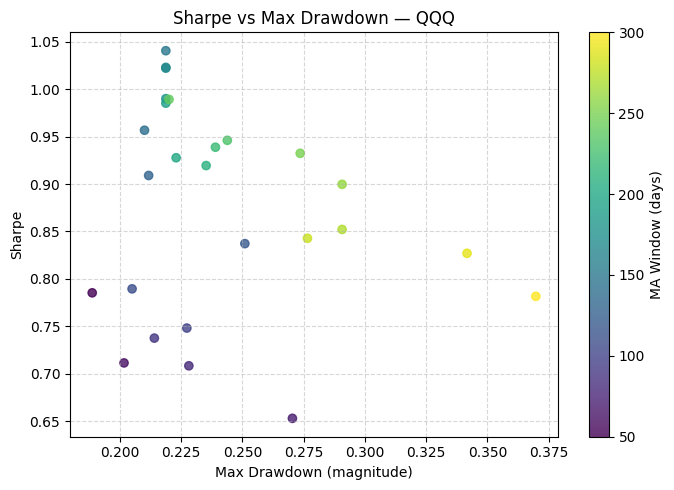

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(res["MaxDD"], res["Sharpe"], c=res.index, alpha=0.8)
plt.xlabel("Max Drawdown (magnitude)")
plt.ylabel("Sharpe")
plt.title(f"Sharpe vs Max Drawdown — {ticker}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(label="MA Window (days)")
plt.tight_layout()
plt.show()


In [11]:
print("\nTop 5 MA windows by Sharpe:")
print(res.sort_values("Sharpe", ascending=False).head())



Top 5 MA windows by Sharpe:
               CAGR    Sharpe     MaxDD
MA_Length                              
150        0.154345  1.040613  0.218756
170        0.151982  1.023050  0.218756
160        0.151390  1.022209  0.218756
180        0.146769  0.990066  0.218756
240        0.149668  0.989279  0.220061
